# Atelier Matplotlib

## Structure du projet
### 4. Installer et importer matplotlib et pandas

In [74]:
import matplotlib.pyplot as plt
import pandas as pd

### 5. Importer mesures_capteurs.csv dans le dataframe df

In [75]:
df = pd.read_csv('../data/mesures_capteurs.csv')
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


## Partie 1 – Graphique linéaire (Line Plot) 
### 1. Afficher l'évolution de la température en fonction du temps, avec le titre, les labels, la légende et la grille.

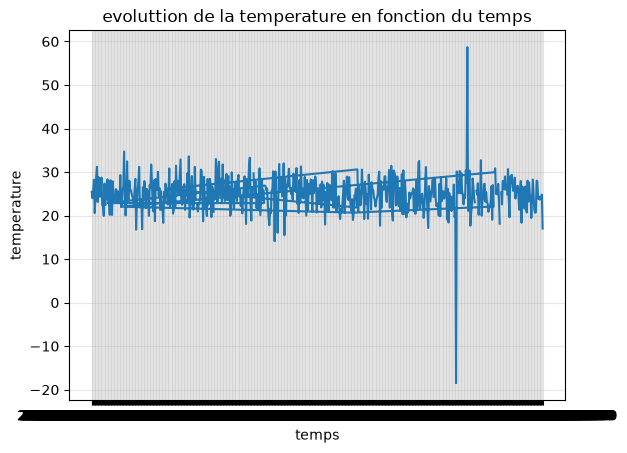

In [76]:
df = pd.read_csv('../data/mesures_capteurs.csv')
fig, ax = plt.subplots()
ax.plot(df['date_heure'],df['temperature'])
plt.title("evoluttion de la temperature en fonction du temps")
plt.xlabel("temps")
plt.ylabel("temperature")
plt.grid(True,alpha=0.3)
plt.show()

### 2. Identifier visuellement les valeurs qui semblent anormales

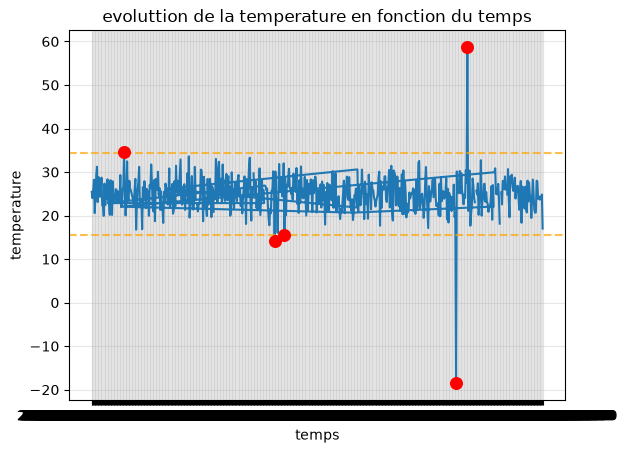

In [77]:
Q1 = df['temperature'].quantile(0.25)
Q3 = df['temperature'].quantile(0.75)
IQR = Q3 - Q1
seuil_bas = Q1 - 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR

anomalies = df[(df['temperature'] < seuil_bas) | (df['temperature'] > seuil_haut)]

fig, ax = plt.subplots()
ax.plot(df['date_heure'],df['temperature'])
plt.scatter(anomalies['date_heure'], anomalies['temperature'], color='red', s=70, label='Valeurs anormales', zorder=5)
plt.axhline(seuil_bas, color='orange', linestyle='--', alpha=0.7, label='Seuil bas')
plt.axhline(seuil_haut, color='orange', linestyle='--', alpha=0.7, label='Seuil haut')

plt.title("evoluttion de la temperature en fonction du temps")
plt.xlabel("temps")
plt.ylabel("temperature")
plt.grid(True,alpha=0.3)
plt.show()



### Explication : Le graphique montre une évolution générale de la température assez régulière, avec quelques écarts brutaux visibles sur la courbe. Ces pics et chutes extrêmes correspondent aux valeurs anormales identifiées en rouge et peuvent refléter des anomalies de mesure.

## Partie 2 – Diagramme en barres (Bar Chart) 
### 1. Déterminer consommation_batiment qui stocke les consommations moyennes des bâtiments

In [78]:
# Calculer la consommation moyenne des bâtiments
consommation_batiment = df.groupby('batiment')['consommation'].mean()
print(consommation_batiment)

batiment
B001    177.870927
B002    221.785333
B003    153.191000
B004    282.552282
Name: consommation, dtype: float64


### 2. Comparer graphiquement la consommation moyenne des bâtiments

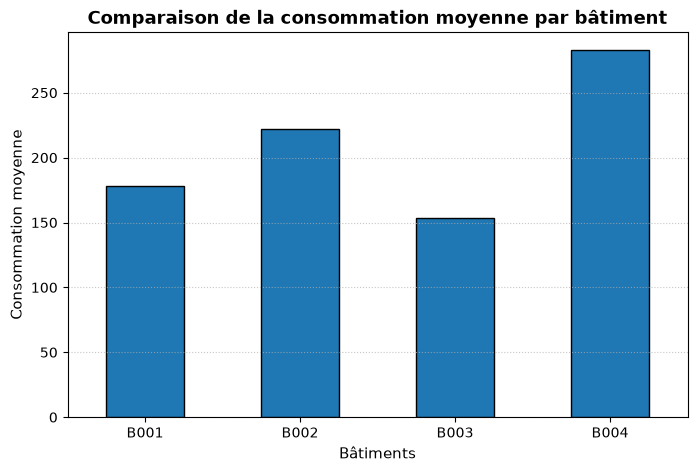

In [79]:
# Création d'une figure de dimension 8x5
plt.figure(figsize=(8, 5))

# Tracé du diagramme en barres verticales
consommation_batiment.plot(kind='bar', edgecolor='black')

# Configuration du titre et des axes
plt.title("Comparaison de la consommation moyenne par bâtiment", fontsize=13, fontweight='bold')
plt.xlabel("Bâtiments", fontsize=11)
plt.ylabel("Consommation moyenne", fontsize=11)
plt.xticks(rotation=0)  # On garde les labels horizontaux
plt.grid(True, axis='y', linestyle=':', alpha=0.7)  # Grille uniquement horizontale
plt.show()

### 3. Comparer la consommation moyenne des bâtiments avec un graphique horizontal

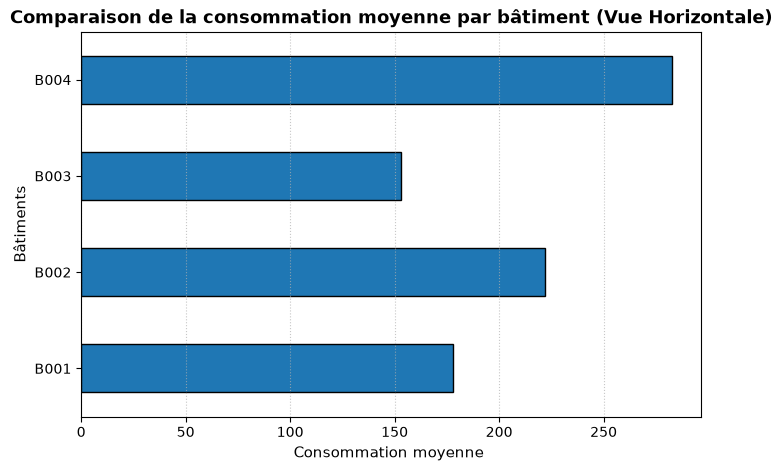

In [80]:
plt.figure(figsize=(8, 5))

# Tracé du diagramme en barres horizontales
consommation_batiment.plot(kind='barh', edgecolor='black')

# Personnalisation
plt.title("Comparaison de la consommation moyenne par bâtiment (Vue Horizontale)", fontsize=13, fontweight='bold')
plt.ylabel("Bâtiments", fontsize=11)
plt.xlabel("Consommation moyenne ", fontsize=11)
plt.grid(True, axis='x', linestyle=':', alpha=0.7)  # Grille uniquement verticale

plt.show()

 
### 4. Dans quels cas un graphique horizontal peut-il être plus lisible ?

**Explication :**
Un graphique en barres horizontales est préférable dans deux scénarios majeurs :
1. **Noms de catégories longs** : Si les labels des catégories contiennent du texte long (ex: "Bâtiment de recherche - Zone Nord"), ils se lisent de gauche à droite naturellement, alors que sur un axe vertical, ils se chevauchent ou doivent être écrits de biais.
2. **Grand nombre de catégories** : Lorsqu'il y a 15 ou 20 catégories à comparer, la lecture de haut en bas est bien plus confortable pour l'œil humain.

## Partie 3 – Histogramme 
### 1. Afficher la distribution des températures en divisant la plage des données en 20 classes et en affichant uniquement les lignes horizontales de la grille

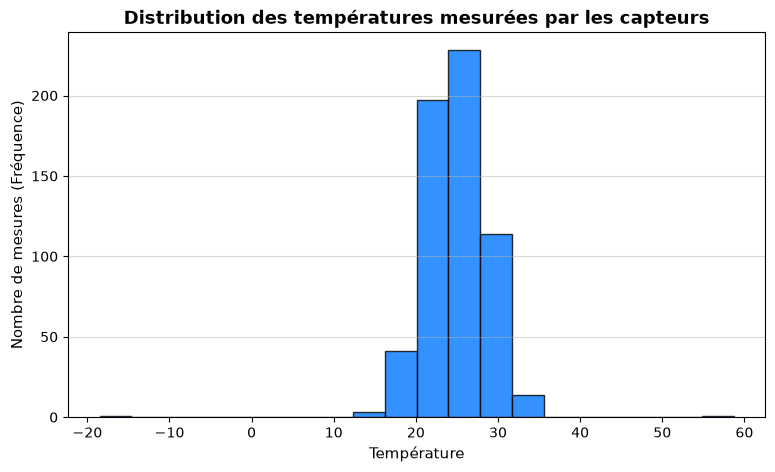

In [81]:
plt.figure(figsize=(9, 5))

# Tracé de l'histogramme de température avec 20 bins (en supprimant les valeurs manquantes avec .dropna())
plt.hist(df['temperature'].dropna(), bins=20, color="#0077ff", edgecolor='black', alpha=0.8)

# Habillage graphique
plt.title("Distribution des températures mesurées par les capteurs", fontsize=13, fontweight='bold')
plt.xlabel("Température", fontsize=11)
plt.ylabel("Nombre de mesures (Fréquence)", fontsize=11)
plt.grid(True, axis='y', alpha=0.5)  # Uniquement les grilles horizontales (Y)

plt.show()

### 2. Analyser le graphique pour voir 
L'analyse de cet histogramme nous montre :
#### a. où se concentrent les températures:
 Les températures se concentrent très majoritairement dans une plage comprise entre **20  et 30**.
#### b. si la distribution semble symétrique :
 La distribution est globalement **symétrique** et prend une forme classique de "cloche" (loi normale) centrée autour de sa moyenne/médiane de **24.8**.
#### c. s'il existe des valeurs très éloignées: 
On distingue clairement à l'œil nu deux petites barres complètement isolées à l'extrême gauche  et à l'extrême droite. Ce sont nos deux anomalies matérielles qui se détachent du comportement global du réseau.
#### d. si des valeurs aberrantes sont visibles : 
Il ya des valeurs aberantes visibles (**-18.5**) et (**58.7C**)